In [1]:
# Canada Per Capita Income capita predict

In [2]:
#step1 : load modules
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from sklearn.linear_model import LinearRegression
import warnings
warnings.filterwarnings('ignore')
print('Done!!')

Done!!


In [3]:
#step2 : import kaggle
import kagglehub

# Download latest version
path = kagglehub.dataset_download("gurdit559/canada-per-capita-income-single-variable-data-set")

print("Path to dataset files:", path)

Path to dataset files: C:\Users\sharm\.cache\kagglehub\datasets\gurdit559\canada-per-capita-income-single-variable-data-set\versions\1


In [4]:
#ste3: File path

File_path = path +'/'+os.listdir(path)[0]

#step 4: Read data
df = pd.read_csv(File_path)
print('Done!!')

Done!!


In [5]:
# step 5: EDA
df.head(5)

,year,per capita income (US$)
0,1970,3399.299037
1,1971,3768.297935
2,1972,4251.175484
3,1973,4804.463248
4,1974,5576.514583


In [6]:
# Data info

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 47 entries, 0 to 46
Data columns (total 2 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   year                     47 non-null     int64  
 1   per capita income (US$)  47 non-null     float64
dtypes: float64(1), int64(1)
memory usage: 884.0 bytes


In [7]:
# df.isna()

In [8]:
df.shape

(47, 2)

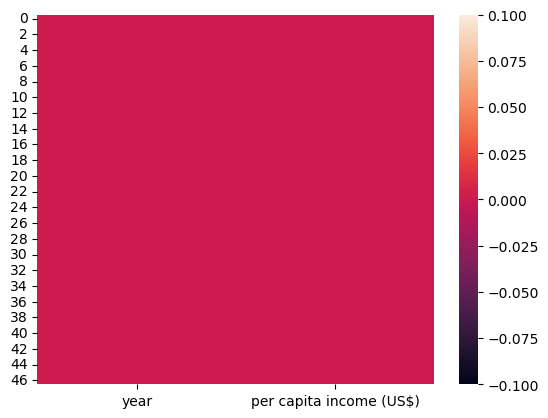

In [9]:
sns.heatmap(df.isna())
plt.show()

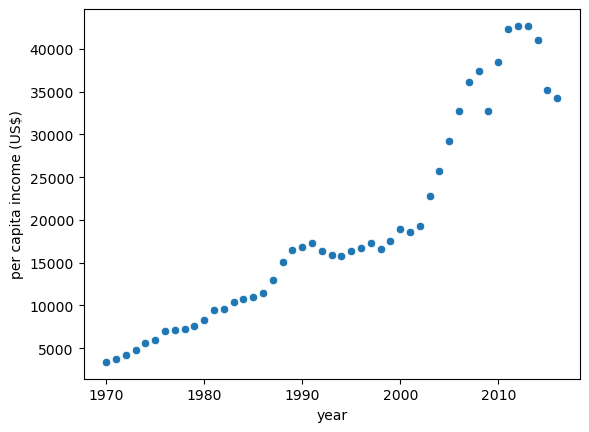

In [10]:
# sns.lineplot(data = df, x = 'year', y = 'per capita income (US$)')
sns.scatterplot(data = df, x = 'year', y = 'per capita income (US$)')
plt.show()

In [11]:
df.corr()

,year,per capita income (US$)
year,1.000000,0.943884
per capita income (US$),0.943884,1.000000


In [12]:
# EDA: detail

In [13]:
df.sample()

,year,per capita income (US$)
22,1992,16412.08309


In [14]:

X = df[['year']]
y = df['per capita income (US$)']

print('Done')

Done


In [15]:
model = LinearRegression()

#training step
model.fit(X,y)  # Hyper Parameters:Model Fine Tune
# Hyper Tune: (data: predict: next future data: false: wrong Prediction)

LinearRegression()

In [16]:
# fiting types : over,under,normal

In [17]:
X.max()

year    2016
dtype: int64

In [18]:
year = [[2018]]

capita = round(model.predict(year)[0],2)

print(f'''per Capita $
{year[0][0]}:{capita}''')

per Capita $
2018:39631.76


In [19]:
y_pred =model.predict(X)
print('Done')

Done


In [20]:
df.sample()

,year,per capita income (US$)
14,1984,10790.32872


In [21]:
df['Predicted Capita'] = y_pred

In [22]:
df.head(10)

,year,per capita income (US$),Predicted Capita
0,1970,3399.299037,-134.559667
1,1971,3768.297935,693.905409
2,1972,4251.175484,1522.370484
3,1973,4804.463248,2350.835559
4,1974,5576.514583,3179.300634
5,1975,5998.144346,4007.765709
6,1976,7062.131392,4836.230785
7,1977,7100.126170,5664.695860
8,1978,7247.967035,6493.160935
9,1979,7602.912681,7321.626010


In [23]:
mae = ((df['per capita income (US$)']-df['Predicted Capita']).abs()).mean()  #Residuals are in between differences

In [24]:
# MAE
from sklearn.metrics import mean_absolute_error

In [25]:
# Evalute()

# mean_absolute_error(y_actual,y_pred)
# y_actual = y
#y_pred = y_pred

MAE = mean_absolute_error(y,y_pred)

In [26]:
print('Manual mae:',mae)
print('Actual mae:',MAE)

Manual mae: 3088.866427771443
Actual mae: 3088.866427771443


In [27]:
mse = ((df['per capita income (US$)']-df['Predicted Capita'])**2).mean()
mse

15462739.061504772

In [28]:
# MSE
from sklearn.metrics import mean_squared_error

In [29]:
MSE = mean_squared_error(y,y_pred)
print(MSE)

15462739.061504772


In [30]:
print('Manual mse:',mse)
print('Actual mse:',MSE)

Manual mse: 15462739.061504772
Actual mse: 15462739.061504772


In [31]:
from sklearn.metrics import root_mean_squared_error

In [32]:
rmse = mse**.5
RMSE = root_mean_squared_error(y,y_pred)

In [33]:
print('Manual rmse:',rmse)
print('Actual rmse:',RMSE)

Manual rmse: 3932.268945723928
Actual rmse: 3932.268945723928


In [34]:
# Model Score

In [35]:
model_score = model.score(X,y)
print('Model Score is:',model_score)

Model Score is: 0.890916917957032


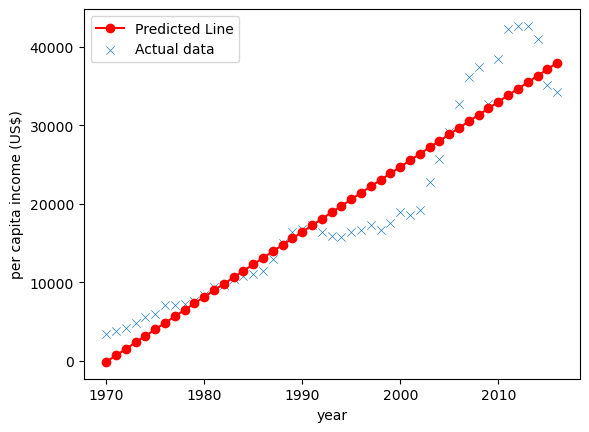

In [36]:
plt.plot(X,y_pred,color = 'red',label = 'Predicted Line',marker= 'o' )
sns.scatterplot(data = df, x = 'year', y = 'per capita income (US$)',marker='x',label = 'Actual data')
plt.legend()
plt.show()

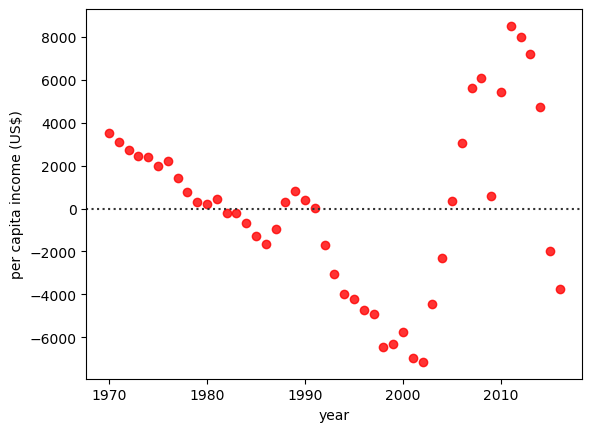

In [37]:
sns.residplot(x=X,y=y,data=df,color='red')
plt.show()

In [80]:
# Last Step: Save
#Model Brain: Ready

In [39]:
import pickle  #pickle:loadand dump:model, Save:file
with open('capita_pred.pkl','wb') as f:
    pickle.dump(model,f)

print('Done!!')

Done!!
